# Reionisation observables from the electron power spectrum

In [1]:
import time
import matplotlib.pyplot as plt
from matplotlib import rc, colors
import numpy as np
from astropy import cosmology, units
import healpy as hp
import os
from scipy.interpolate import interp1d

In [2]:
from matplotlib import cm, colors, rcParams

In [3]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

In [4]:
import camb
from camb import model, initialpower

In [5]:
from theory import Pee_model
from utils import *

In [6]:
rc("font", **{"family": "serif", "serif": ["times new roman"], "size": 18})
rc("text", usetex=True)
rc("axes", linewidth=1.5)

In [7]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [8]:
ells = np.arange(50, 10000, step=250)

In [9]:
cos = cosmology.Planck18

## Consistent reionisation observables: power spectra

The `Pee_model` class allows you to compute the kSZ angular power spectrum, the optical depth power spectrum, and the 21cm power spectrum, all following a consistent reionsation model, based on the electron power spectrum parameterisation introduced in Gorce et. al 2020.

In [10]:
preion_model = Pee_model(
    h=cos.h,
    Ob_0=cos.Ob0,
    Om_0=cos.Om0,
    verbose=True, run_camb=True)

zre_h = 7.0, zend = 5.5
Late-time ionisation fraction: 1.16
tau = 0.0603
Running CAMB...


Text(0.5, 1.0, '$z=7.0$')

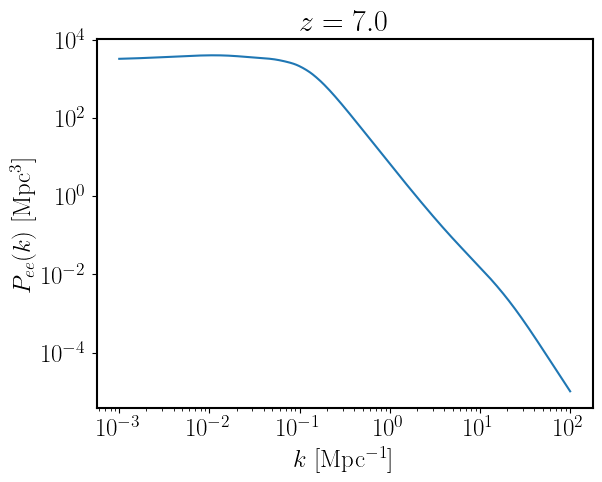

In [11]:
klog = np.logspace(-3, 2, 500)

plt.figure()
plt.loglog(klog, preion_model.Pee(klog, preion_model.zre_h))
plt.xlabel(r'$k$ [Mpc$^{-1}$]')
plt.ylabel(r'$P_{ee}(k)$ [Mpc$^3$]')
plt.title(rf'$z={preion_model.zre_h:.1f}$')

### Reionisation history

Text(0, 0.5, 'Reionisation history')

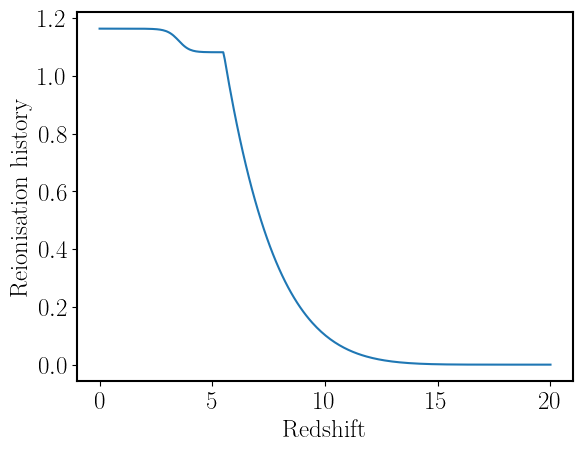

In [12]:
z = np.linspace(0, 20, 300)

plt.figure()
plt.plot(z, preion_model.xe(z))
plt.xlabel(r'Redshift')
plt.ylabel(r'Reionisation history')

0.05337984560807982


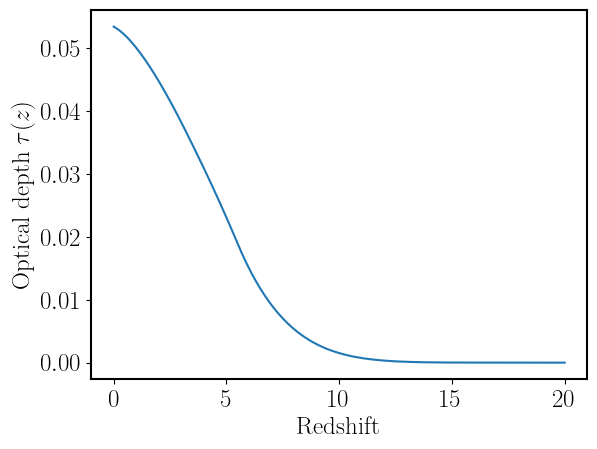

In [13]:
plt.figure()
plt.plot(z, preion_model.xe2tau(z))
plt.xlabel(r'Redshift')
plt.ylabel(r'Optical depth $\tau(z)$')
print(preion_model.xe2tau(z)[0])

### Primary power spectra

The class also computes primary power spectra:

In [14]:
CMB_Cells = preion_model.get_primary_spectra(ells=np.linspace(1, 4000, 200), Dells=True)

 Computing CMB power spectra...


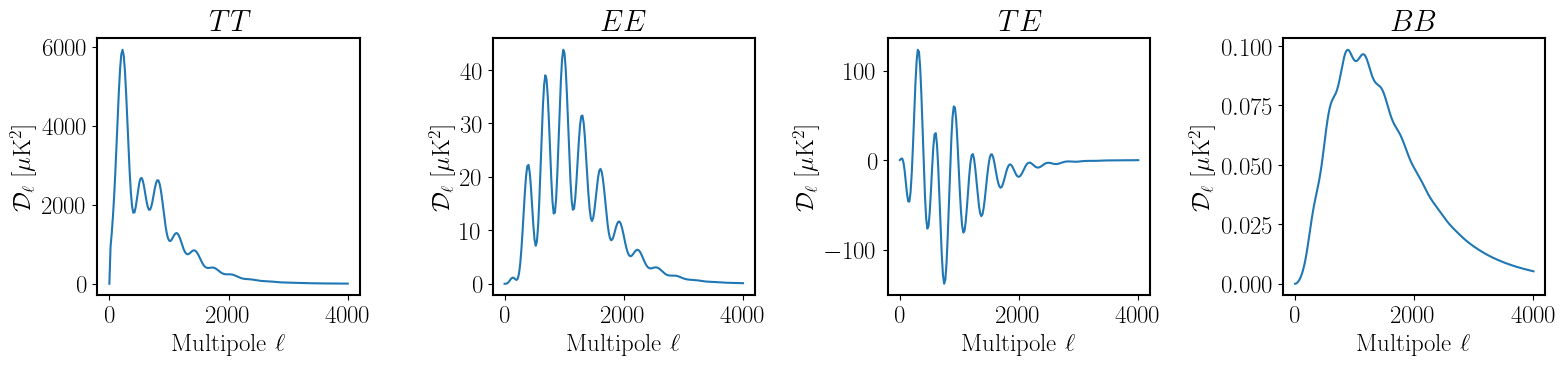

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for u, (ax, label) in enumerate(zip(axes,
                                   [r'$TT$', r'$EE$', r'$TE$', r'$BB$'])):
    ax.plot(CMB_Cells[:, 0], CMB_Cells[:, u+1])
    ax.set_ylabel(rf'$\mathcal{{D}}_\ell$ [$\mu$K$^2$]')
    ax.set_title(label)
    ax.set_xlabel(r'Multipole $\ell$')
fig.tight_layout()

### kSZ power spectrum

#### Fiducial model

To compute the kSZ power spectrum, use the `get_ksz` method. 
The following will output the kSZ power on a range of multipoles `ells` as $\mathcal{D}_\ell = T_\mathrm{CMB} \ell (\ell + 1) C_\ell / 2 \pi$.

In [16]:
ksz_file = 'data/ref_ksz.txt'
if os.path.exists(ksz_file):
    ksz_ps = np.loadtxt(ksz_file, unpack=True)[1:].T
else:
    t0 = time.time()
    ksz_ps = preion_model.get_ksz(ells=ells, signal='both', Dells=True)
    t1 = time.time()
    print(f'Computation took {t1-t0:.1f} seconds.')
    np.savetxt(ksz_file, np.c_[ells, ksz_ps], header='ells, Dells ksz')

In [17]:
i3000 = np.argmin(np.abs(3000-ells))
print(f'At l=3000, [atchy power = {ksz_ps[i3000, 0]:.1f} uK2, late-time power = {ksz_ps[i3000, 1]:.1f} uK2')

At l=3000, [atchy power = 1.2 uK2, late-time power = 3.1 uK2


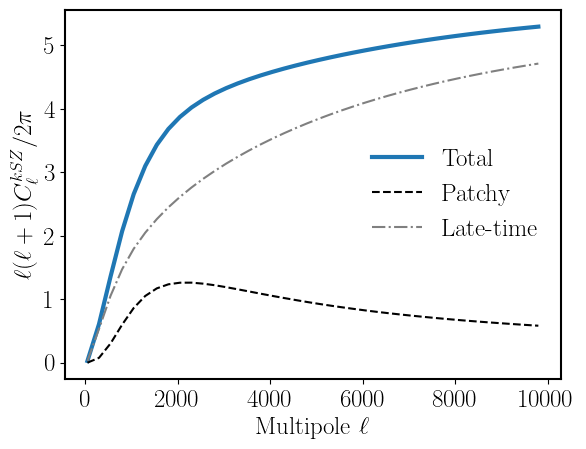

In [18]:
plt.figure()
plt.plot(ells, np.sum(ksz_ps, axis=1), label='Total', lw=3.)
plt.plot(ells, ksz_ps[:, 0], label='Patchy', ls='--', color='k')
plt.plot(ells, ksz_ps[:, 1], label='Late-time', ls='-.', color='grey')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell(\ell+1)C_\ell^{kSZ}/2\pi$')
# plt.ylim(1e-5, 1e-2)
plt.legend(frameon=False)
# plt.xlim(0, 3000)

### $\tau$ power spectrum

To compute the $\tau-\tau$ power spectrum, use the `get_tau` method. 
The following will output the tau power on a range of multipoles `ells` as $\mathcal{D}_\ell = T_\mathrm{CMB} \ell (\ell + 1) C_\ell / 2 \pi$.

#### Fiducial model

In [19]:
tau_ps = preion_model.get_tau(ells=ells, signal='both', Dells=True)


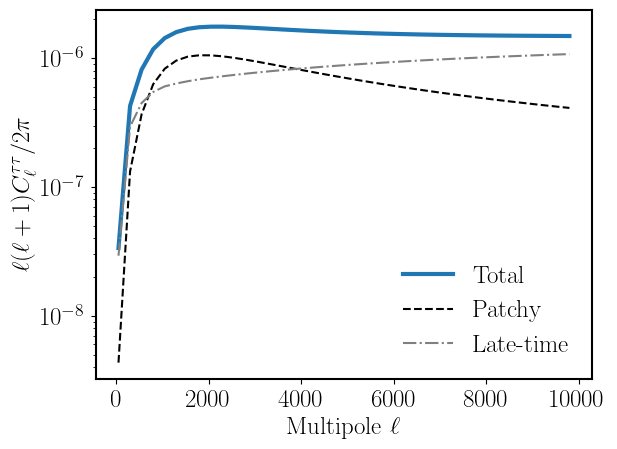

In [20]:
plt.figure()
plt.semilogy(ells, np.sum(tau_ps, axis=1), label='Total', lw=3.)
plt.plot(ells, tau_ps[:, 0], label='Patchy', ls='--', color='k')
plt.plot(ells, tau_ps[:, 1], label='Late-time', ls='-.', color='grey')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell(\ell+1)C_\ell^{\tau\tau}/2\pi$')
# plt.ylim(1e-5, 1e-2)
plt.legend(frameon=False)
# plt.xlim(0, 3000)

### 21cm power spectrum

To compute the 21cm power spectrum, use the `get_p21(k,z)` method.

In [21]:
zarr = np.linspace(5., 10, 20)
karr = np.logspace(-3, 1, 100)

ps_21 = preion_model.get_p21(karr, zarr[:, None], mK=True, log=False, pk_units=True)

Text(0, 0.5, 'Reionisation history')

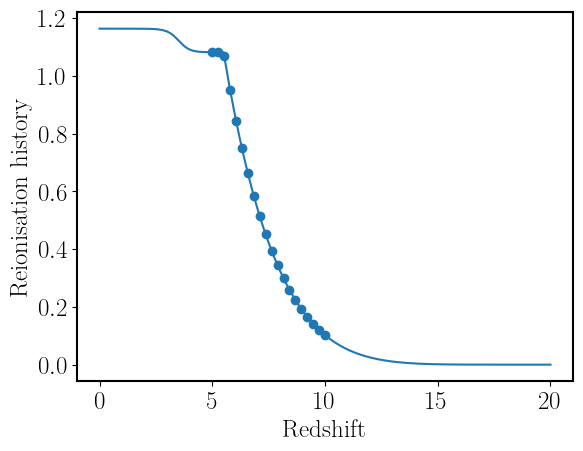

In [22]:
z = np.linspace(0, 20, 300)

plt.figure()
plt.plot(z, preion_model.xe(z))
plt.scatter(zarr, preion_model.xe(zarr))
plt.xlabel(r'Redshift')
plt.ylabel(r'Reionisation history')

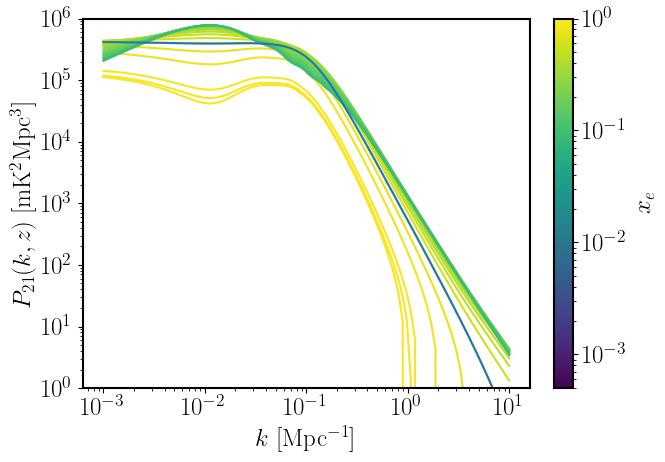

In [23]:
cmap = colormaps['viridis']
norm = colors.LogNorm(vmin=5e-4, vmax=1.)

fig, ax = plt.subplots()
for iz, z in enumerate(zarr):
    ax.loglog(karr, ps_21[iz], color=cmap(norm(preion_model.xe(z)[0]/preion_model.f)))
ax.plot(karr, ps_21[5])
ax.set_ylim(1e0, 1e6)
ax.set_xlabel(r'$k$ [Mpc$^{-1}]$')
ax.set_ylabel(r'$P_{21}(k, z)$ [mK$^2$Mpc$^3]$')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
c_bar = plt.colorbar(sm, fraction=0.05, label=r'$x_e$', ax=ax)

### $BB$ power spectrum

In [24]:
low_ells = np.logspace(0, 4, 100)

In [93]:
pars = preion_model.def_camb()
pars.set_for_lmax(int(low_ells.max()), lens_potential_accuracy=2)
pars.WantTensors = True
results = camb.get_transfer_functions(pars)
inflation_params = initialpower.InitialPowerLaw()

inflation_params.set_params(ns=preion_model.n_s, r=0.)
results.power_spectra_from_transfer(inflation_params) #warning OK here, not changing scalars
primary_bb = results.get_total_cls(int(low_ells.max()), CMB_unit='muK')[:, 2]

inflation_params.set_params(ns=preion_model.n_s, r=0.1)
results.power_spectra_from_transfer(inflation_params) #warning OK here, not changing scalars
lensed_bb = results.get_total_cls(int(low_ells.max()), CMB_unit='muK')[:, 2]

a) Scattering $B$-modes

In [27]:
scattering_bb = preion_model.get_scattering_B_modes(ells=low_ells, signal='both', Dells=True)

b) Screening $B$-modes

In [28]:
screening_bb = preion_model.get_screening_B_modes(ells=low_ells, Dells=True)

 Computing CMB power spectra...


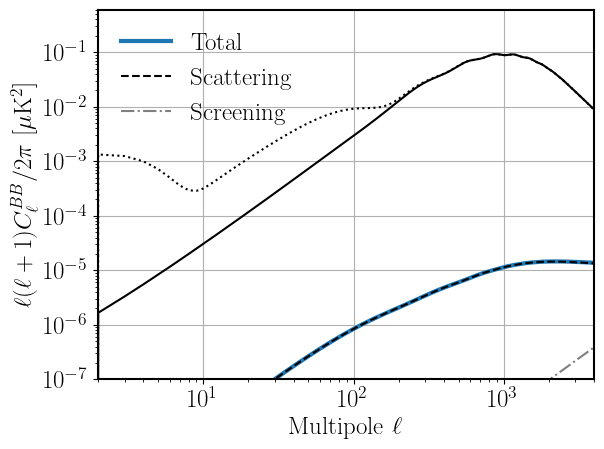

In [90]:
plt.figure()
plt.loglog(low_ells, np.sum(scattering_bb, axis=1)+screening_bb, label='Total', lw=3.)
plt.plot(low_ells, np.sum(scattering_bb, axis=1), label='Scattering', ls='--', color='k')
plt.plot(low_ells, screening_bb, label='Screening', ls='-.', color='grey')
plt.plot(np.arange(int(low_ells.max())+1), primary_bb, color='k')
plt.plot(np.arange(int(low_ells.max())+1), lensed_bb, color='k', ls=':')
plt.xlabel(r'Multipole $\ell$')
plt.ylabel(r'$\ell(\ell+1)C_\ell^{BB}/2\pi$ [$\mu$K$^2$]')
plt.ylim(1e-7, 6e-1)
plt.legend(frameon=False, loc='upper left')
plt.xlim(2, 4000)
plt.grid()

### All observables

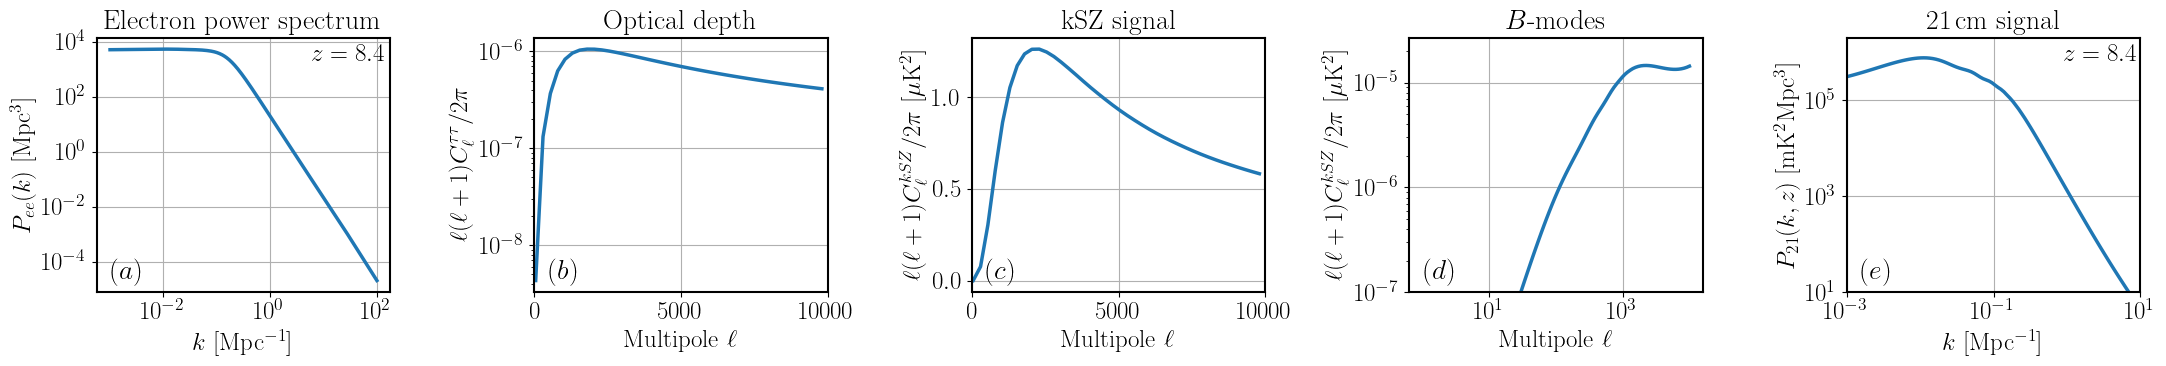

In [30]:
zref = 8.4
props = dict(boxstyle="round", facecolor="white", alpha=0.5)

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
# pee
axes[0].loglog(klog, preion_model.Pee(klog, zref), lw=2.5)
axes[0].set_xlabel(r'$k$ [Mpc$^{-1}$]')
axes[0].set_ylabel(r'$P_{ee}(k)$ [Mpc$^3$]')
axes[0].text(6, 2000, rf'$z={zref:.1f}$')#, bbox=props)
# tau
axes[1].semilogy(ells, tau_ps[:, 0], ls='-', color='C0', lw=2.5)
axes[1].set_xlabel(r'Multipole $\ell$')
axes[1].set_ylabel(r'$\ell(\ell+1)C_\ell^{\tau\tau}/2\pi$')
# axes[1].set_ylim(bottom=1e-6)
axes[1].set_xlim(0, 10000)

# ksz
axes[2].plot(ells, ksz_ps[:, 0], lw=2.5)
axes[2].set_xlabel(r'Multipole $\ell$')
axes[2].set_ylabel(r'$\ell(\ell+1)C_\ell^{kSZ}/2\pi$ [$\mu$K$^2$]')
axes[2].set_xlim(0, 10000)

# B-modes
axes[3].loglog(low_ells, np.sum(scattering_bb, axis=1)+screening_bb, lw=2.5)
axes[3].set_xlabel(r'Multipole $\ell$')
axes[3].set_ylabel(r'$\ell(\ell+1)C_\ell^{kSZ}/2\pi$ [$\mu$K$^2$]')
axes[3].set_ylim(bottom=1e-7)

# 21cm ps
axes[4].loglog(karr, preion_model.get_p21(karr, zref, mK=True, log=False, pk_units=True), lw=2.5)
axes[4].set_ylim(bottom=1e0)
axes[4].set_xlabel(r'$k$ [Mpc$^{-1}]$')
axes[4].set_ylabel(r'$P_{21}(k, z)$ [mK$^2$Mpc$^3]$')
axes[4].set_xlim(1e-3, 10)
axes[4].set_ylim(10, 2e6)
axes[4].text(.9, 6.5e5, rf'$z={zref:.1f}$')#, bbox=props)

for i, (letter, title) in enumerate(zip(['a', 'b', 'c', 'd', 'e'],
                                        ['Electron power spectrum', 'Optical depth', 'kSZ signal', r'$B$-modes', '21\,cm signal'])):
    axes[i].set_title(title, fontsize=20)
    axes[i].grid()
    axes[i].text(0.05, 0.05, rf'$({letter})$', transform=axes[i].transAxes, fontsize=20)
fig.tight_layout()
fig.savefig('model2observables_ps_2.png', dpi=220)

## Detectability

We want to compare our signals to the telescope noise and sample variance, and to the primary CMB and other foregrounds.

In [148]:
# fsky, fwhm, map noise
cmap = colormaps['Set2']
colors = [cmap(x) for x in np.linspace(0, 1, 10)]

telescope_specs = {
    'SPT-3G': {'fsky':0.036, 'fwhm':1.3, 'noise':14.0, 'color':colors[0]},
    'AdvACT': {'fsky':0.5, 'fwhm':1.5, 'noise':13.2, 'color':colors[1]},
    'SO': {'fsky':0.4, 'fwhm':2.0, 'noise':3.0, 'color':colors[2]},
    'CMB-S4': {'fsky':0.6, 'fwhm':1.0, 'noise':np.sqrt(2.), 'color':colors[3]},
    'CMB-HD': {'fsky':0.5, 'fwhm':0.5, 'noise':2.7, 'color':colors[4]},
    'LiteBIRD': {'fsky':1., 'fwhm':30., 'noise':2.4, 'color':colors[5]},
    'PICO': {'fsky':1., 'fwhm':7.9, 'noise':.85, 'color':colors[6]},
}


In [71]:
def sample_var(ls, dl, telescope, bin_width=100):
    if np.shape(ls) != np.shape(dl):
        raise ValueError('ls and dl must have the same shape.')
    # lrange = np.arange(int(ls.max()))
    # drange = interp1d(ls, dl, fill_value='extrapolate')
    dDl = dl * np.sqrt(2./telescope['fsky']/(2.*ls+1.))
    # sum_l = 
    # dDl = dl * 1./np.sqrt(telescope['fsky']/2.(2.*ls+1.))
    return dDl

In [106]:
(1. / 60.0 * np.pi / 180.0), (1.*units.arcmin).to(units.rad)

(0.0002908882086657216, <Quantity 0.00029089 rad>)

In [72]:
def noise(ls, telescope, pol=False, is_cl=False):
    ls = np.atleast_1d(ls)
    sig0 = telescope['noise'] / 60.0 * np.pi / 180.0 # arcmin to rad
    fwhm = telescope['fwhm'] / 60.0 * np.pi / 180.0 # arcmin to rad
    nl = sig0**2 / 2. * np.exp(ls*(ls+1.)*fwhm**2/8./np.log(2.))
    if pol:
        nl *= 2.
    if not is_cl:
        nl *= ls*(ls+1.)/2./np.pi
    return nl

/var/folders/2p/wqfydjvd3snd75pbf0j8mc3m0000gn/T/ipykernel_20862/3895460939.py:5: RuntimeWarning: overflow encountered in exp
  nl = sig0**2 / 2. * np.exp(ls*(ls+1.)*fwhm**2/8./np.log(2.))


Text(0.5, 0, 'Multipole $\\ell$')

/Users/adeliegorce/opt/anaconda3/envs/camb/lib/python3.9/site-packages/matplotlib/scale.py:255: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


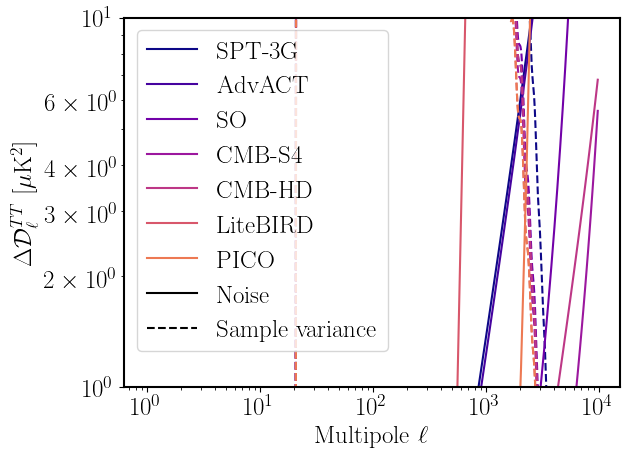

In [146]:
fig, ax = plt.subplots(1, 1)
for i, tel in enumerate(telescope_specs.keys()):
    ax.loglog(ells, noise(ells, telescope_specs[tel], pol=False), ls='-', color=telescope_specs[tel]['color'])
    ax.plot(CMB_Cells[:, 0], sample_var(CMB_Cells[:, 0], CMB_Cells[:, 1], telescope_specs[tel]), ls='--', color=telescope_specs[tel]['color'])
    ax.plot([], [], color=telescope_specs[tel]['color'], label=tel)
ax.plot([], [], color='k', label='Noise')
ax.plot([], [], color='k', ls='--', label='Sample variance')
ax.legend(ncol=1)
ax.set_ylabel(r'$\Delta \mathcal{D}_\ell^{TT}$ [$\mu$K$^2$]')
ax.set_xlabel(r'Multipole $\ell$')

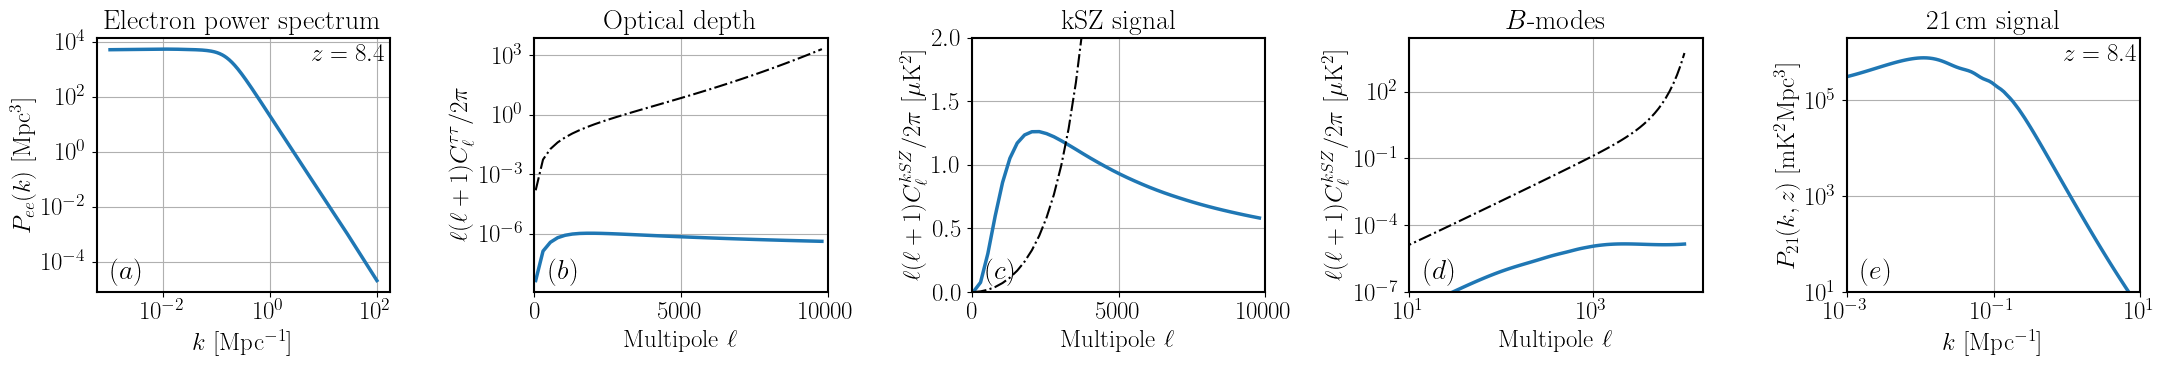

In [83]:
tel = 'SO'
zref = 8.4
props = dict(boxstyle="round", facecolor="white", alpha=0.5)

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
# pee
axes[0].loglog(klog, preion_model.Pee(klog, zref), lw=2.5)
axes[0].set_xlabel(r'$k$ [Mpc$^{-1}$]')
axes[0].set_ylabel(r'$P_{ee}(k)$ [Mpc$^3$]')
axes[0].text(6, 2000, rf'$z={zref:.1f}$')#, bbox=props)
# tau
axes[1].semilogy(ells, tau_ps[:, 0], ls='-', color='C0', lw=2.5)
axes[1].plot(ells, noise(ells, telescope_specs[tel], pol=False), ls='-.', color='k')
axes[1].set_xlabel(r'Multipole $\ell$')
axes[1].set_ylabel(r'$\ell(\ell+1)C_\ell^{\tau\tau}/2\pi$')
# axes[1].set_ylim(bottom=1e-6)
axes[1].set_xlim(0, 10000)

# ksz
axes[2].plot(ells, ksz_ps[:, 0], lw=2.5)
axes[2].plot(ells, noise(ells, telescope_specs[tel], pol=False), ls='-.', color='k')
axes[2].set_xlabel(r'Multipole $\ell$')
axes[2].set_ylabel(r'$\ell(\ell+1)C_\ell^{kSZ}/2\pi$ [$\mu$K$^2$]')
axes[2].set_xlim(0, 10000)
axes[2].set_ylim(0, 2)

# B-modes
axes[3].loglog(low_ells, np.sum(scattering_bb, axis=1)+screening_bb, lw=2.5)
axes[3].plot(low_ells, noise(low_ells, telescope_specs[tel], pol=True), ls='-.', color='k')
axes[3].set_xlabel(r'Multipole $\ell$')
axes[3].set_ylabel(r'$\ell(\ell+1)C_\ell^{kSZ}/2\pi$ [$\mu$K$^2$]')
axes[3].set_ylim(bottom=1e-7)
axes[3].set_xlim(left=10)

# 21cm ps
axes[4].loglog(karr, preion_model.get_p21(karr, zref, mK=True, log=False, pk_units=True), lw=2.5)
axes[4].set_ylim(bottom=1e0)
axes[4].set_xlabel(r'$k$ [Mpc$^{-1}]$')
axes[4].set_ylabel(r'$P_{21}(k, z)$ [mK$^2$Mpc$^3]$')
axes[4].set_xlim(1e-3, 10)
axes[4].set_ylim(10, 2e6)
axes[4].text(.9, 6.5e5, rf'$z={zref:.1f}$')#, bbox=props)

for i, (letter, title) in enumerate(zip(['a', 'b', 'c', 'd', 'e'],
                                        ['Electron power spectrum', 'Optical depth', 'kSZ signal', r'$B$-modes', '21\,cm signal'])):
    axes[i].set_title(title, fontsize=20)
    axes[i].grid()
    axes[i].text(0.05, 0.05, rf'$({letter})$', transform=axes[i].transAxes, fontsize=20)
fig.tight_layout()
# fig.savefig('model2observables_ps_2.png', dpi=220)

/var/folders/2p/wqfydjvd3snd75pbf0j8mc3m0000gn/T/ipykernel_20862/3895460939.py:5: RuntimeWarning: overflow encountered in exp
  nl = sig0**2 / 2. * np.exp(ls*(ls+1.)*fwhm**2/8./np.log(2.))


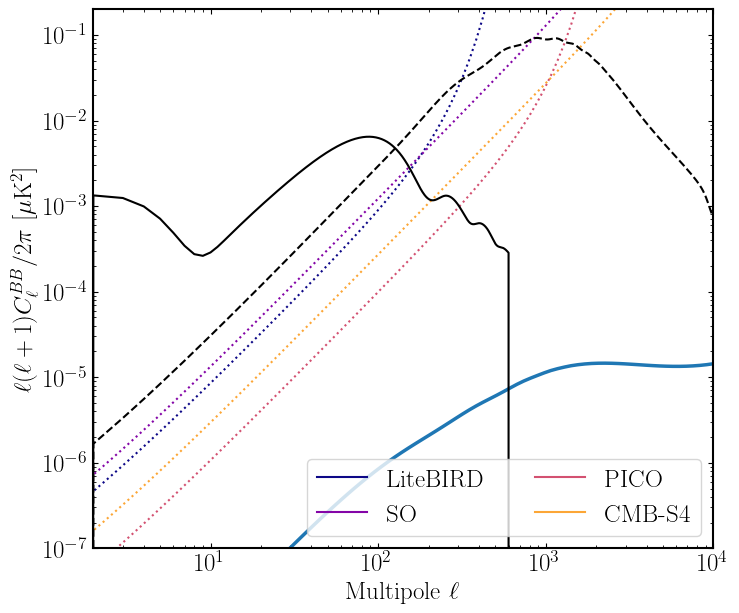

In [122]:
colors = [cmap(x) for x in np.linspace(0, .8, 4)]
fig, ax = plt.subplots(1, 1, figsize=(8, 7))
ax.loglog(low_ells, np.sum(scattering_bb, axis=1)+screening_bb, lw=2.5)
# ax.grid()
for i, tel in enumerate(['LiteBIRD', 'SO', 'PICO', 'CMB-S4']):
    ax.plot(low_ells, noise(low_ells, telescope_specs[tel], pol=True), ls=':', color=colors[i])
    ax.plot([], [], color=colors[i], label=tel)
ax.plot(np.arange(int(low_ells.max())+1), primary_bb, color='k', ls='--')
ax.plot(np.arange(int(low_ells.max())+1), lensed_bb-primary_bb, color='k', ls='-')
ax.set_xlabel(r'Multipole $\ell$')
ax.set_ylabel(r'$\ell(\ell+1)C_\ell^{BB}/2\pi$ [$\mu$K$^2$]')
ax.set_ylim(1e-7, 0.2)
ax.set_xlim(2., 1e4)
ax.legend(ncol=2)
ax.tick_params(axis="both", direction="in", which='both', right=True, top=True)


## For a range of parameter values

In [31]:
from scipy.stats import qmc
import corner
# import emul_sz
from tqdm import tqdm

In [32]:
params = ['zre', 'dz', 'alpha0', 'kappa']
param_labels = [r'$z_\mathrm{re}$', r'd$z$', r'log$\alpha_0$', r'log$\kappa$']
nparams = len(params)
bounds = np.array([(6., 10.), (0.1, 4.0), (2.5, 4.5), (-2, -.5)])
def_params = [7.0, 1.5, 3.7, -1.]

In [33]:
obs_list = [r'$\tau\tau$', 'kSZ', r'$BB$']

In [34]:
preion_model_temp = Pee_model(
    h=cos.h,
    Ob_0=cos.Ob0,
    Om_0=cos.Om0,
    verbose=False, run_camb=True)

### Independent variation

In [35]:
ntest = 10
value_arr = np.array([np.linspace(bounds[i, 0], bounds[i, 1], ntest) for i in range(nparams)])

In [36]:
zlin = np.linspace(0, 20, 300)

In [37]:
ksz_arr = np.zeros((nparams, ntest, ells.size))
tau_arr = np.zeros((nparams, ntest, ells.size))
bb_arr = np.zeros((nparams, ntest, low_ells.size))
xe_arr = np.zeros((nparams, ntest, zlin.size))
pee_arr = np.zeros((nparams, ntest, klog.size))

for i in range(nparams):
    print(params[i])
    for u in range(ntest):

        paramset = np.copy(def_params)
        paramset[i] = value_arr[i, u]
        preion_model_temp.zre_h = paramset[0]
        preion_model_temp.dz_h = paramset[1]
        preion_model_temp.alpha0 = paramset[2]
        preion_model_temp.kappa = 10**paramset[3]
        # print(paramset)
        preion_model_temp.init_reionisation_history()

        pee_arr[i, u, :] = preion_model_temp.Pee(klog, paramset[0])
        xe_arr[i, u, :] = preion_model_temp.xe(zlin)
        tau_arr[i, u, :] = preion_model_temp.get_tau(ells=ells, signal='both', Dells=True)[:, 0]
        bb_arr[i, u, :] = preion_model_temp.get_B_modes(ells=low_ells, Dells=True, Qrms=17.0)


zre
dz
alpha0
kappa


/var/folders/2p/wqfydjvd3snd75pbf0j8mc3m0000gn/T/ipykernel_20862/1432729322.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = truncate_colormap(cm.get_cmap('PuRd'), 0.3, 1.0)


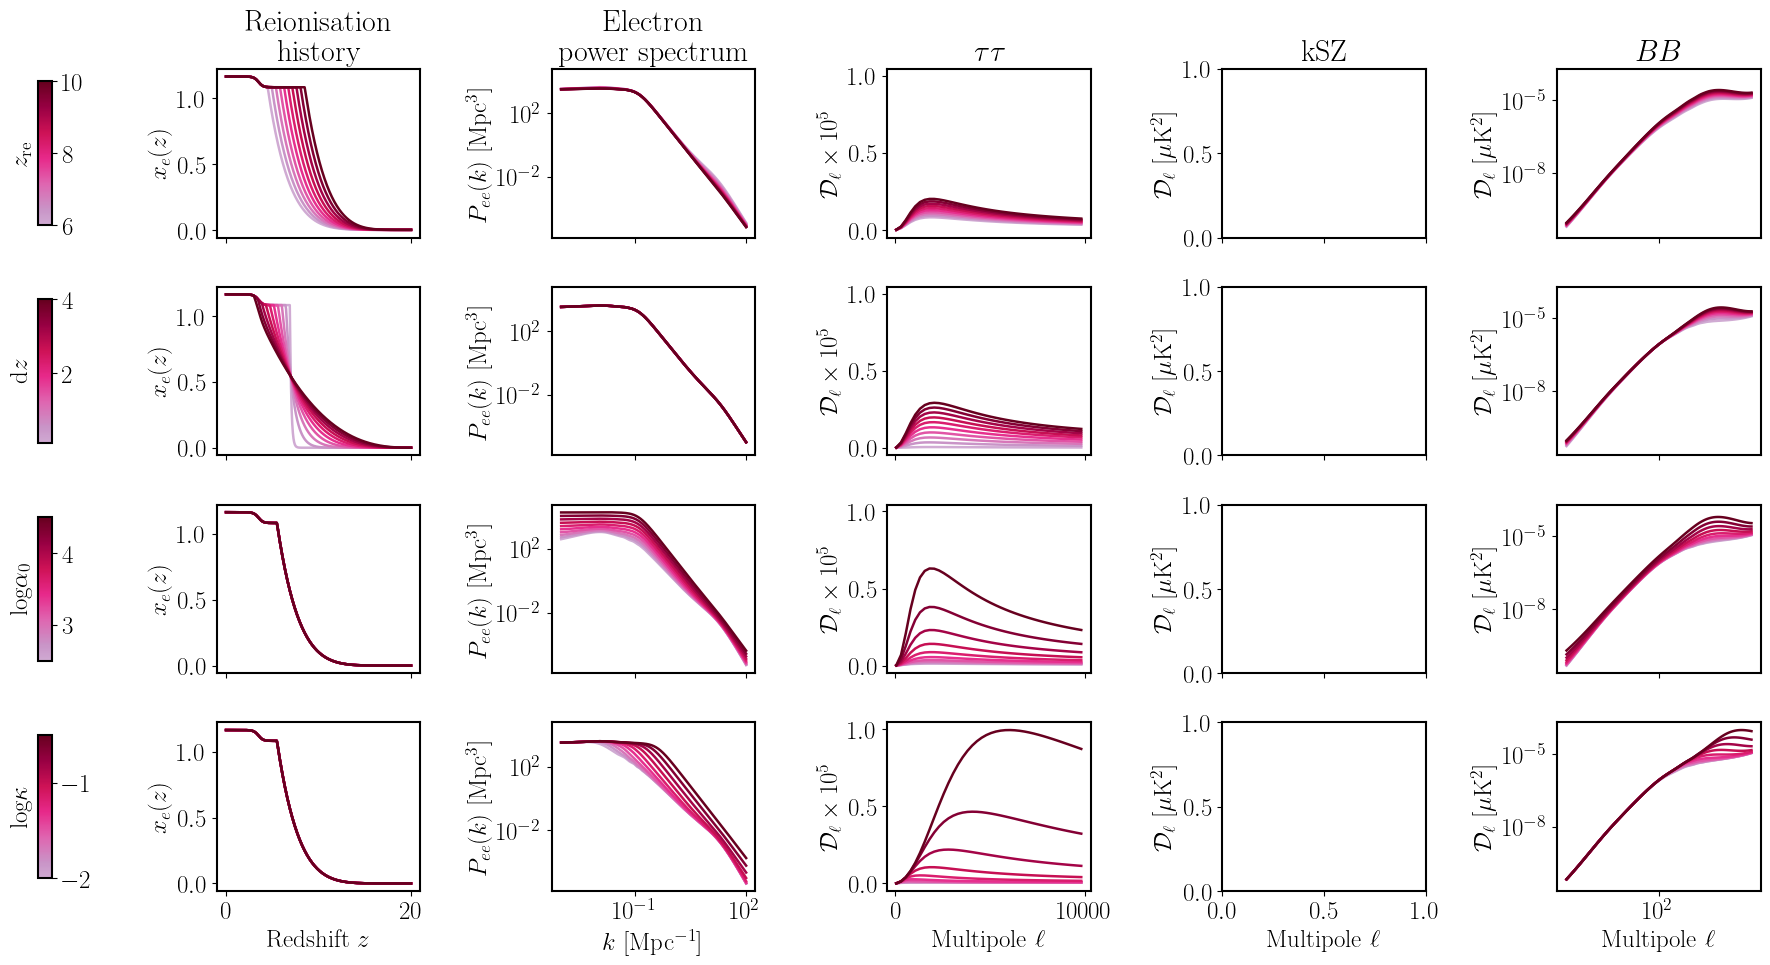

In [38]:
fig, axes = plt.subplots(
    nparams, 6, figsize=(18, 10),
    sharex='col', sharey='col', 
    gridspec_kw={'width_ratios':(1,3,3,3,3,3)})
fig.subplots_adjust(left=0.02,wspace=0.35, hspace=0.04, top=0.98, right=0.98, bottom=0.05)
for i in range(nparams):

    # sys.stdout.flush()
    cmap = truncate_colormap(cm.get_cmap('PuRd'), 0.3, 1.0)
    norm = colors.Normalize(vmin=bounds[i, 0], vmax=bounds[i, 1]) #can also use LogNorm

    axes[i, 0].set_visible(False)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    c_bar=plt.colorbar(sm, ax=axes[i, 0], shrink=.85, fraction=.7, aspect=10, label=param_labels[i])
    c_bar.ax.yaxis.set_label_position('left')

    for u in range(ntest):
        c = cmap(norm(value_arr[i, u]))
        axes[i, 1].plot(zlin, xe_arr[i, u], color=c, lw=1.8)
        axes[i, 2].loglog(klog, pee_arr[i, u], color=c,lw=1.8,ls='-')
        axes[i, 3].plot(ells, tau_arr[i, u]*1e5, color=c, lw=1.8, ls='-')
        # axes[i, 4].loglog(ells, ksz_arr[i, u], color=c,lw=1.8,ls='-')
        axes[i, 5].loglog(low_ells, bb_arr[i, u], color=c, lw=1.8, ls='-')

for j, (ylab, title) in enumerate(zip(
        [r'$x_e(z)$', r'$P_{ee}(k)$ [Mpc$^3$]', r'$\mathcal{D}_\ell \times 10^5$', r'$\mathcal{D}_\ell$ [$\mu$K$^2$]', r'$\mathcal{D}_\ell$ [$\mu$K$^2$]'],
        ['Reionisation\n history', 'Electron \n power spectrum']+obs_list)):
    axes[0, j+1].set_title(title)
    if j > 1:
        axes[-1, j+1].set_xlabel(r'Multipole $\ell$')
    for i in range(nparams):
        axes[i, j+1].set_ylabel(ylab)
axes[-1, 1].set_xlabel(r'Redshift $z$')
axes[-1, 2].set_xlabel(r'$k$ [Mpc$^{-1}$]')

fig.tight_layout()
fig.savefig('model_vs_param_ind.pdf', dpi=220)

### Latin hypercube and simultaneous variation

In [123]:
nsamples = 500

In [124]:
sampler = qmc.LatinHypercube(d=nparams)
sample = sampler.random(n=nsamples)
sample = qmc.scale(
    sample,
    bounds[:, 0],
    bounds[:, 1]
)

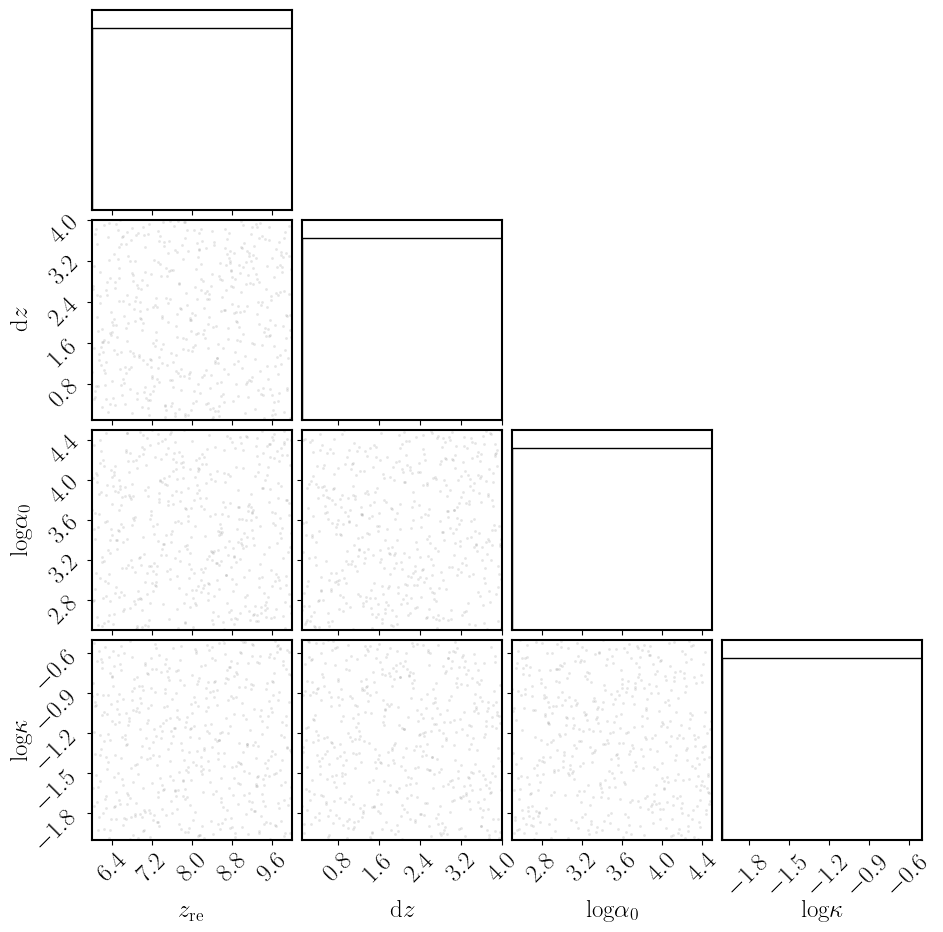

In [125]:
fig = corner.corner(sample, labels=param_labels, plot_density=False, plot_contours=False, plot_datapoints=True, range=bounds)

In [126]:
pee_list = []
tau_ps_list = []
bb_list = []
ksz_list = []
for paramset in tqdm(sample):
    preion_model_temp.zre_h = paramset[0]
    preion_model_temp.dz_h = paramset[1]
    preion_model_temp.alpha0 = paramset[2]
    preion_model_temp.kappa = 10**paramset[3]
    preion_model_temp.init_reionisation_history()

    pee_list.append(preion_model.Pee(klog, paramset[0]))
    tau_ps_list.append(preion_model_temp.get_tau(ells=ells, signal='both', Dells=True)[:, 0])
    bb_list.append(preion_model_temp.get_B_modes(ells=low_ells, Dells=True, Qrms=17.0))
tau_ps_list = np.array(tau_ps_list)
bb_list = np.array(bb_list)
pee_list = np.array(pee_list)
# ksz_list = np.array(ksz_list)

100%|██████████| 500/500 [24:01<00:00,  2.88s/it]


/var/folders/2p/wqfydjvd3snd75pbf0j8mc3m0000gn/T/ipykernel_20862/3895460939.py:5: RuntimeWarning: overflow encountered in exp
  nl = sig0**2 / 2. * np.exp(ls*(ls+1.)*fwhm**2/8./np.log(2.))


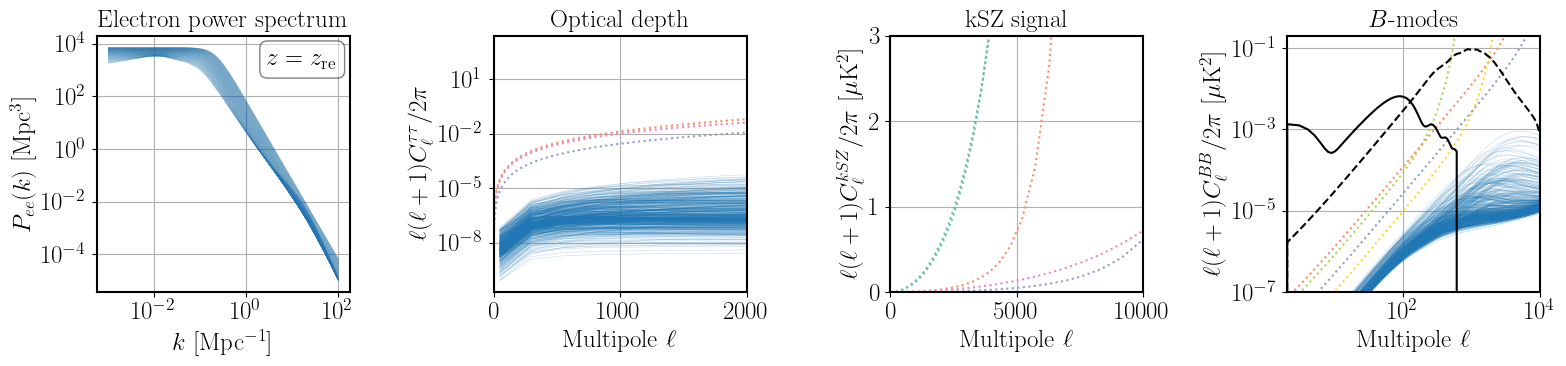

In [155]:
delta_lbin = 100.

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
# pee
axes[0].loglog(klog, pee_list.T, color='C0', lw=.2, alpha=.1)
axes[0].set_xlabel(r'$k$ [Mpc$^{-1}$]')
axes[0].set_ylabel(r'$P_{ee}(k)$ [Mpc$^3$]')
axes[0].text(.95, .95, r'$z=z_\mathrm{re}$', bbox=props, transform=axes[0].transAxes, ha='right', va='top')


# tau
axes[1].semilogy(ells, tau_ps_list.T, color='C0', lw=.5, alpha=.2)
axes[1].set_xlabel(r'Multipole $\ell$')
axes[1].set_ylabel(r'$\ell(\ell+1)C_\ell^{\tau\tau}/2\pi$')
# axes[1].set_ylim(bottom=1e-6)
axes[1].set_xlim(0, 2000)
for i, tel in enumerate(['SO', 'CMB-S4', 'CMB-HD']):
    axes[1].plot(low_ells, noise(low_ells, telescope_specs[tel], pol=True)/np.sqrt(delta_lbin), ls=':', color=telescope_specs[tel]['color'])
    axes[1].plot([], [], color=telescope_specs[tel]['color'], label=tel)

# ksz
# axes[2].plot(ells, ksz_list.T, color='k', lw=.5, alpha=.2)
axes[2].set_xlabel(r'Multipole $\ell$')
axes[2].set_ylabel(r'$\ell(\ell+1)C_\ell^{kSZ}/2\pi$ [$\mu$K$^2$]')
axes[2].set_xlim(0, 10000)
for i, tel in enumerate(['SPT-3G', 'AdvACT', 'SO', 'CMB-S4', 'CMB-HD']):
    axes[2].plot(low_ells, noise(low_ells, telescope_specs[tel], pol=False)/np.sqrt(delta_lbin), ls=':', color=telescope_specs[tel]['color'])
    axes[2].plot([], [], color=telescope_specs[tel]['color'], label=tel)
axes[2].set_ylim(0, 3)
# B-modes
axes[3].loglog(low_ells, bb_list.T, color='C0', lw=.5, alpha=.2)
axes[3].set_xlabel(r'Multipole $\ell$')
axes[3].set_ylabel(r'$\ell(\ell+1)C_\ell^{BB}/2\pi$ [$\mu$K$^2$]')
# detectability
for i, tel in enumerate(['LiteBIRD', 'SO', 'PICO', 'CMB-S4']):
    axes[3].plot(low_ells, noise(low_ells, telescope_specs[tel], pol=True)/np.sqrt(delta_lbin), ls=':', color=telescope_specs[tel]['color'])
    axes[3].plot([], [], color=telescope_specs[tel]['color'], label=tel)
axes[3].plot(np.arange(int(low_ells.max())+1), primary_bb, color='k', ls='--')
axes[3].plot(np.arange(int(low_ells.max())+1), lensed_bb-primary_bb, color='k', ls='-')
axes[3].set_ylim(1e-7, 0.2)
axes[3].set_xlim(2., 1e4)

for i, (letter, title) in enumerate(zip(['a', 'b', 'c', 'd'],
                                        ['Electron power spectrum', 'Optical depth', 'kSZ signal', r'$B$-modes'])):
    axes[i].set_title(title, fontsize=18)
    axes[i].grid()
    # axes[i].text(0.05, 0.05, rf'$({letter})$', transform=axes[i].transAxes, fontsize=20)
fig.tight_layout()
fig.savefig('models_vs_params.png', dpi=220)